# Notebook 13 — Reducción de dimensionalidad con PCA

En este notebook estudiaremos cómo Principal Component Analysis (PCA) transforma variables correlacionadas en nuevas direcciones ortogonales que concentran la mayor cantidad posible de varianza.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la intuición geométrica de PCA;
- comprender por qué el centrado y escalamiento importan;
- ajustar PCA con `scikit-learn`;
- interpretar componentes principales;
- analizar varianza explicada y varianza acumulada;
- seleccionar un número razonable de componentes;
- inspeccionar loadings;
- reconstruir aproximadamente los datos originales;
- utilizar PCA dentro de un `Pipeline`;
- analizar el efecto de PCA sobre un clasificador;
- reconocer la pérdida de interpretabilidad y otras limitaciones.

Usaremos datos sintéticos correlacionados y un problema de clasificación generado con `scikit-learn`.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Intuición geométrica con datos bidimensionales

Generaremos dos variables fuertemente correlacionadas.

En este caso, gran parte de la variabilidad se concentra a lo largo de una dirección inclinada.

In [2]:
n_samples = 350

latent = rng.normal(size=n_samples)

x1 = 2.5 * latent + rng.normal(0, 0.35, size=n_samples)
x2 = 1.3 * latent + rng.normal(0, 0.25, size=n_samples)

X_2d = pd.DataFrame({
    "x1": x1,
    "x2": x2,
})

X_2d.head()


,x1,x2
0,0.8907,0.6744
1,-2.3037,-1.4132
2,1.6763,0.7179
3,2.6362,1.2085
4,-4.5036,-2.2741


In [3]:
X_2d.corr()


,x1,x2
x1,1.0000,0.9706
x2,0.9706,1.0000


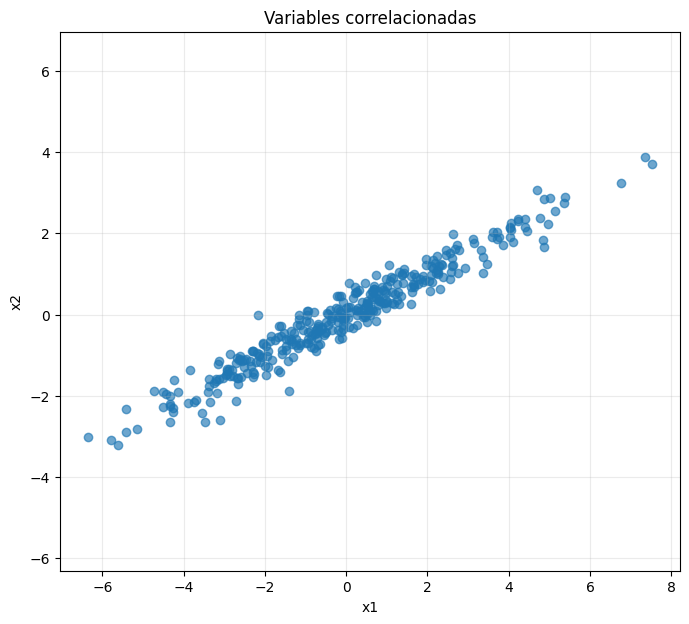

In [4]:
plt.figure(figsize=(8, 7))
plt.scatter(
    X_2d["x1"],
    X_2d["x2"],
    alpha=0.65,
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Variables correlacionadas")
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()


## 3. Centrado, escalamiento y ajuste de PCA

PCA busca direcciones de máxima varianza.

Si las variables tienen escalas muy distintas, una variable puede dominar el análisis únicamente por sus unidades.

Por eso, en muchos problemas se estandariza antes de aplicar PCA.

In [5]:
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

pca_2d = PCA(n_components=2)
X_2d_pca = pca_2d.fit_transform(X_2d_scaled)

print("Varianza explicada:")
print(pca_2d.explained_variance_ratio_)

print()
print("Varianza acumulada:")
print(np.cumsum(pca_2d.explained_variance_ratio_))


Varianza explicada:
[0.98531942 0.01468058]

Varianza acumulada:
[0.98531942 1.        ]


La primera componente principal captura la dirección de mayor variabilidad.  
La segunda es ortogonal a la primera y captura la variabilidad restante.

In [6]:
components_2d = pd.DataFrame(
    pca_2d.components_,
    columns=["x1", "x2"],
    index=["PC1", "PC2"],
)

components_2d


,x1,x2
PC1,0.7071,0.7071
PC2,-0.7071,0.7071


Cada fila de `components_` contiene los pesos utilizados para construir una componente.

Por ejemplo:

\[
PC_1=w_{11}x_1+w_{12}x_2.
\]

Los signos pueden invertirse sin cambiar la solución geométrica.

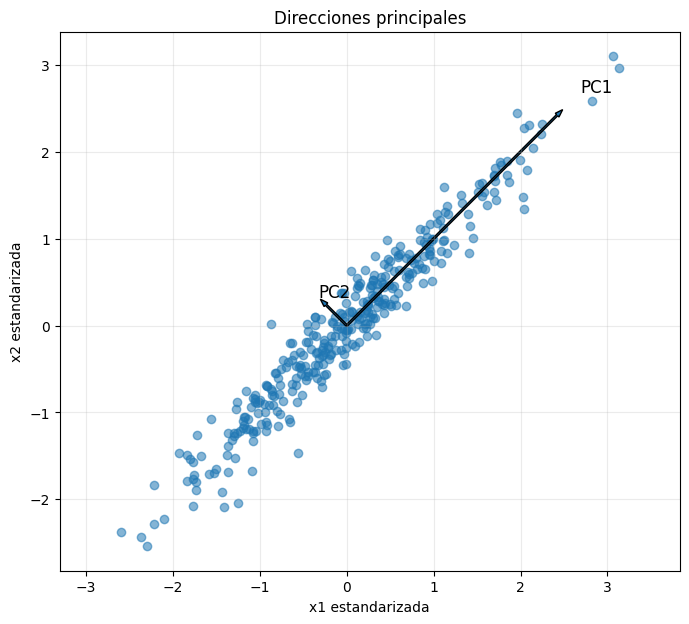

In [7]:
origin = np.array([0.0, 0.0])

plt.figure(figsize=(8, 7))
plt.scatter(
    X_2d_scaled[:, 0],
    X_2d_scaled[:, 1],
    alpha=0.55,
)

for index, component in enumerate(pca_2d.components_):
    vector = (
        component
        * np.sqrt(pca_2d.explained_variance_[index])
        * 2.5
    )

    plt.arrow(
        origin[0],
        origin[1],
        vector[0],
        vector[1],
        width=0.02,
        length_includes_head=True,
    )

    plt.text(
        vector[0] * 1.08,
        vector[1] * 1.08,
        f"PC{index + 1}",
        fontsize=12,
    )

plt.xlabel("x1 estandarizada")
plt.ylabel("x2 estandarizada")
plt.title("Direcciones principales")
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()


## 4. Datos expresados en el espacio de componentes

Después de la transformación, las componentes son incorrelacionadas dentro de la muestra.

In [8]:
X_2d_pca_df = pd.DataFrame(
    X_2d_pca,
    columns=["PC1", "PC2"],
)

X_2d_pca_df.corr()


,PC1,PC2
PC1,1.0000,0.0000
PC2,0.0000,1.0000


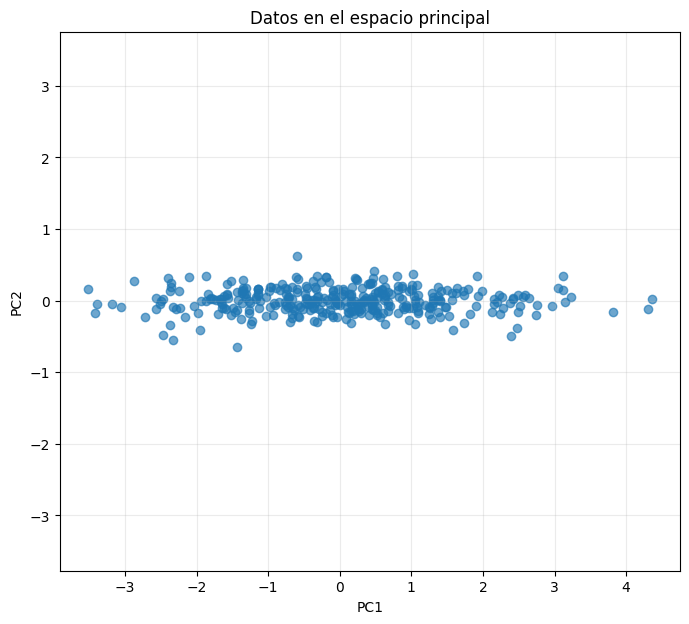

In [9]:
plt.figure(figsize=(8, 7))
plt.scatter(
    X_2d_pca_df["PC1"],
    X_2d_pca_df["PC2"],
    alpha=0.65,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Datos en el espacio principal")
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()


## 5. Reducción de dos dimensiones a una

Conservaremos únicamente PC1.

In [10]:
pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X_2d_scaled)

print(
    "Varianza retenida:",
    pca_1d.explained_variance_ratio_[0],
)


Varianza retenida: 0.9853194185172788


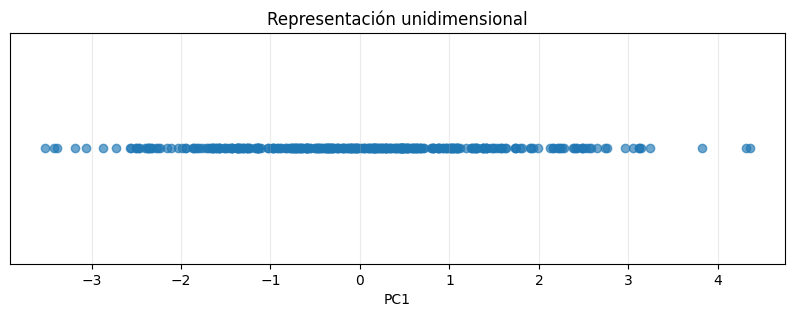

In [11]:
plt.figure(figsize=(10, 3))
plt.scatter(
    X_1d[:, 0],
    np.zeros_like(X_1d[:, 0]),
    alpha=0.65,
)
plt.xlabel("PC1")
plt.yticks([])
plt.title("Representación unidimensional")
plt.grid(axis="x", alpha=0.25)
plt.show()


La reducción pierde información, pero puede conservar gran parte de la estructura si la primera componente explica una proporción elevada de la varianza.

## 6. Reconstrucción aproximada

PCA puede transformar los datos de regreso al espacio original mediante `inverse_transform`.

Cuando se conservan menos componentes, la reconstrucción es aproximada.

In [12]:
X_2d_reconstructed_scaled = pca_1d.inverse_transform(
    X_1d
)

X_2d_reconstructed = scaler_2d.inverse_transform(
    X_2d_reconstructed_scaled
)

reconstruction_error = np.mean(
    (X_2d.to_numpy() - X_2d_reconstructed) ** 2
)

print(
    "Error cuadrático medio de reconstrucción:",
    reconstruction_error,
)


Error cuadrático medio de reconstrucción: 0.05461078108895082


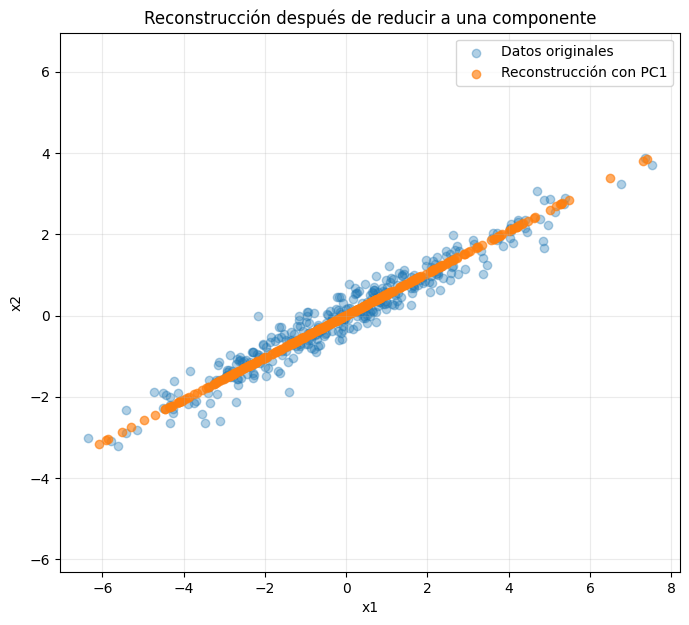

In [13]:
plt.figure(figsize=(8, 7))
plt.scatter(
    X_2d["x1"],
    X_2d["x2"],
    alpha=0.35,
    label="Datos originales",
)
plt.scatter(
    X_2d_reconstructed[:, 0],
    X_2d_reconstructed[:, 1],
    alpha=0.65,
    label="Reconstrucción con PC1",
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Reconstrucción después de reducir a una componente")
plt.legend()
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()


## 7. PCA con varias variables

Generaremos un dataset de clasificación con variables informativas, redundantes y ruido.

In [14]:
X_multi, y_multi = make_classification(
    n_samples=1_200,
    n_features=14,
    n_informative=5,
    n_redundant=5,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.4,
    flip_y=0.03,
    random_state=RANDOM_STATE,
)

feature_names = [
    f"x_{index}"
    for index in range(1, X_multi.shape[1] + 1)
]

X_multi = pd.DataFrame(
    X_multi,
    columns=feature_names,
)

y_multi = pd.Series(
    y_multi,
    name="clase",
)

print(X_multi.shape)
X_multi.head()


(1200, 14)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,x_11,x_12,x_13,x_14
0,-0.3580,3.9991,-3.5480,0.3489,-2.3417,-1.2348,-1.0940,3.0768,0.6851,-1.3440,0.5023,0.8841,-0.0785,2.7400
1,-1.7225,4.3622,-1.7579,-0.2182,-2.6580,1.7928,-1.5658,-0.3880,-1.2103,-2.2113,1.8192,1.4282,1.5433,1.6102
2,0.4857,1.3258,1.5706,1.6087,1.5420,1.2545,-2.5940,-0.0833,0.9840,-1.4832,1.7333,1.7293,0.4982,-5.2855
3,-1.2700,-2.8651,4.2781,1.0866,-1.4644,4.2990,0.3253,-6.1968,0.0492,-0.2692,0.5448,-0.1930,0.9731,-1.4182
4,0.8631,-6.6915,0.8042,-0.4055,1.6359,-1.4306,2.2415,3.5700,0.0908,0.0354,0.5591,-1.7180,-5.0454,-4.6171


## 8. Varianza explicada por componente

Ajustaremos PCA conservando todas las componentes para estudiar cuánto aporta cada una.

In [15]:
scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(
    X_multi
)

pca_full = PCA()
pca_full.fit(
    X_multi_scaled
)

explained_variance_table = pd.DataFrame({
    "Componente": np.arange(
        1,
        len(pca_full.explained_variance_ratio_) + 1,
    ),
    "Varianza explicada": (
        pca_full.explained_variance_ratio_
    ),
    "Varianza acumulada": np.cumsum(
        pca_full.explained_variance_ratio_
    ),
})

explained_variance_table


,Componente,Varianza explicada,Varianza acumulada
0,1,0.2903,0.2903
1,2,0.2095,0.4998
2,3,0.1148,0.6146
3,4,0.0779,0.6925
4,5,0.0753,0.7678
5,6,0.0700,0.8378
6,7,0.0677,0.9055
7,8,0.0655,0.9710
8,9,0.0290,1.0000
9,10,0.0000,1.0000


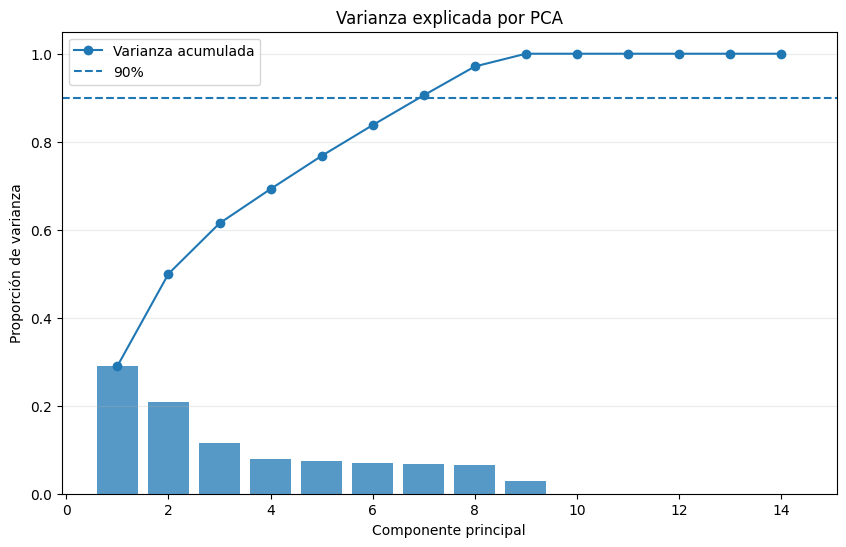

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    explained_variance_table["Componente"],
    explained_variance_table["Varianza explicada"],
    alpha=0.75,
)

plt.plot(
    explained_variance_table["Componente"],
    explained_variance_table["Varianza acumulada"],
    marker="o",
    label="Varianza acumulada",
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%",
)

plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza")
plt.title("Varianza explicada por PCA")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## 9. Selección del número de componentes

Podemos elegir:

- un número fijo;
- una proporción objetivo de varianza.

Por ejemplo:

```python
PCA(n_components=0.90)
```

conserva el número mínimo de componentes necesario para explicar al menos 90% de la varianza.

In [17]:
pca_90 = PCA(
    n_components=0.90
)

X_multi_pca_90 = pca_90.fit_transform(
    X_multi_scaled
)

print(
    "Componentes retenidas:",
    pca_90.n_components_,
)

print(
    "Varianza total retenida:",
    pca_90.explained_variance_ratio_.sum(),
)


Componentes retenidas: 7
Varianza total retenida: 0.9055047280323436


## 10. Visualización en dos componentes

Reduciremos a dos dimensiones únicamente con fines visuales.

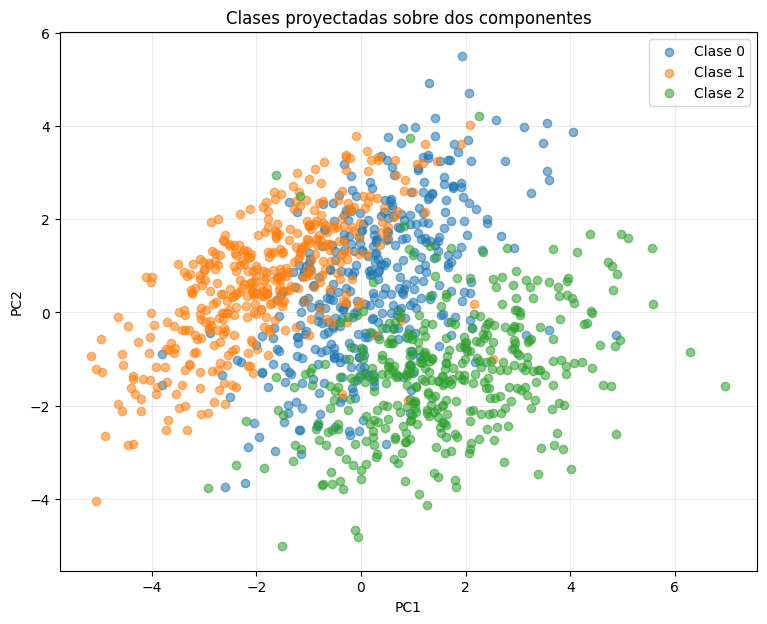

In [18]:
pca_visual = PCA(
    n_components=2
)

X_multi_2d = pca_visual.fit_transform(
    X_multi_scaled
)

plt.figure(figsize=(9, 7))

for class_value in sorted(y_multi.unique()):
    mask = y_multi == class_value

    plt.scatter(
        X_multi_2d[mask, 0],
        X_multi_2d[mask, 1],
        alpha=0.55,
        label=f"Clase {class_value}",
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clases proyectadas sobre dos componentes")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


PCA no utiliza las etiquetas. Por eso las primeras componentes no necesariamente son las mejores para separar clases; maximizan varianza, no discriminación.

## 11. Loadings

Los loadings muestran cómo contribuyen las variables originales a cada componente.

In [19]:
loadings = pd.DataFrame(
    pca_visual.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"],
)

loadings


,PC1,PC2
x_1,-0.0311,0.0322
x_2,0.4352,-0.2183
x_3,-0.1367,0.5227
x_4,0.0060,0.0036
x_5,-0.3430,0.1138
x_6,0.2542,0.4816
x_7,-0.4024,0.0390
x_8,-0.2266,-0.4208
x_9,-0.0258,-0.0265
x_10,-0.3481,-0.0964


In [20]:
loading_magnitudes = loadings.abs()

print("Variables con mayor contribución a PC1")
display(
    loading_magnitudes["PC1"]
    .sort_values(ascending=False)
    .head(8)
)

print("Variables con mayor contribución a PC2")
display(
    loading_magnitudes["PC2"]
    .sort_values(ascending=False)
    .head(8)
)


Variables con mayor contribución a PC1


x_2    0.4352
x_13   0.4113
x_7    0.4024
x_10   0.3481
x_5    0.3430
x_14   0.2821
x_6    0.2542
x_8    0.2266
Name: PC1, dtype: float64

Variables con mayor contribución a PC2


x_3    0.5227
x_6    0.4816
x_8    0.4208
x_14   0.3645
x_11   0.3300
x_2    0.2183
x_5    0.1138
x_10   0.0964
Name: PC2, dtype: float64

Un loading grande en magnitud indica una contribución importante a la componente.

El signo representa dirección, no importancia absoluta.

## 12. PCA dentro de un pipeline de clasificación

Compararemos regresión logística:

- con todas las variables;
- con PCA reteniendo 90% de la varianza.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    stratify=y_multi,
    random_state=RANDOM_STATE,
)

logistic_without_pca = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=3_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

logistic_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    (
        "pca",
        PCA(
            n_components=0.90,
        ),
    ),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=3_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

logistic_without_pca.fit(
    X_train,
    y_train,
)

logistic_with_pca.fit(
    X_train,
    y_train,
)

predictions_without_pca = logistic_without_pca.predict(
    X_test
)

predictions_with_pca = logistic_with_pca.predict(
    X_test
)

comparison = pd.DataFrame({
    "Modelo": [
        "Regresión logística sin PCA",
        "Regresión logística con PCA",
    ],
    "Accuracy test": [
        accuracy_score(
            y_test,
            predictions_without_pca,
        ),
        accuracy_score(
            y_test,
            predictions_with_pca,
        ),
    ],
    "F1 macro test": [
        f1_score(
            y_test,
            predictions_without_pca,
            average="macro",
        ),
        f1_score(
            y_test,
            predictions_with_pca,
            average="macro",
        ),
    ],
})

comparison


,Modelo,Accuracy test,F1 macro test
0,Regresión logística sin PCA,0.9033,0.9036
1,Regresión logística con PCA,0.8933,0.8938


In [22]:
print(
    "Número de componentes usadas en el pipeline:",
    logistic_with_pca.named_steps["pca"].n_components_,
)


Número de componentes usadas en el pipeline: 7


PCA puede:

- reducir dimensionalidad;
- eliminar redundancia;
- acelerar algunos modelos;
- estabilizar problemas con colinealidad.

Pero también puede:

- perder información predictiva;
- dificultar la interpretación;
- no mejorar el desempeño si las variables originales ya son adecuadas.

## 13. ¿Qué ocurre si no escalamos?

Construiremos una copia donde una variable se multiplica por un factor grande.

In [23]:
X_unscaled_example = X_multi.copy()
X_unscaled_example["x_1"] = (
    X_unscaled_example["x_1"] * 100_000
)

pca_without_scaling = PCA(
    n_components=2
)

X_pca_without_scaling = pca_without_scaling.fit_transform(
    X_unscaled_example
)

print(
    "Varianza explicada sin escalamiento:",
    pca_without_scaling.explained_variance_ratio_,
)


Varianza explicada sin escalamiento: [9.99999995e-01 2.28426493e-09]


Sin escalamiento, la variable de mayor magnitud puede dominar la primera componente, aunque no sea la más informativa conceptualmente.

## 14. Error de reconstrucción según el número de componentes

Conservaremos diferentes cantidades de componentes y mediremos el error de reconstrucción.

In [24]:
reconstruction_rows = []

for n_components in range(1, X_multi.shape[1] + 1):
    pca_model = PCA(
        n_components=n_components
    )

    transformed = pca_model.fit_transform(
        X_multi_scaled
    )

    reconstructed = pca_model.inverse_transform(
        transformed
    )

    reconstruction_mse = np.mean(
        (X_multi_scaled - reconstructed) ** 2
    )

    reconstruction_rows.append({
        "Número de componentes": n_components,
        "Varianza retenida": (
            pca_model.explained_variance_ratio_.sum()
        ),
        "Error de reconstrucción": reconstruction_mse,
    })

reconstruction_table = pd.DataFrame(
    reconstruction_rows
)

reconstruction_table.head()


,Número de componentes,Varianza retenida,Error de reconstrucción
0,1,0.2903,0.7097
1,2,0.4998,0.5002
2,3,0.6146,0.3854
3,4,0.6925,0.3075
4,5,0.7678,0.2322


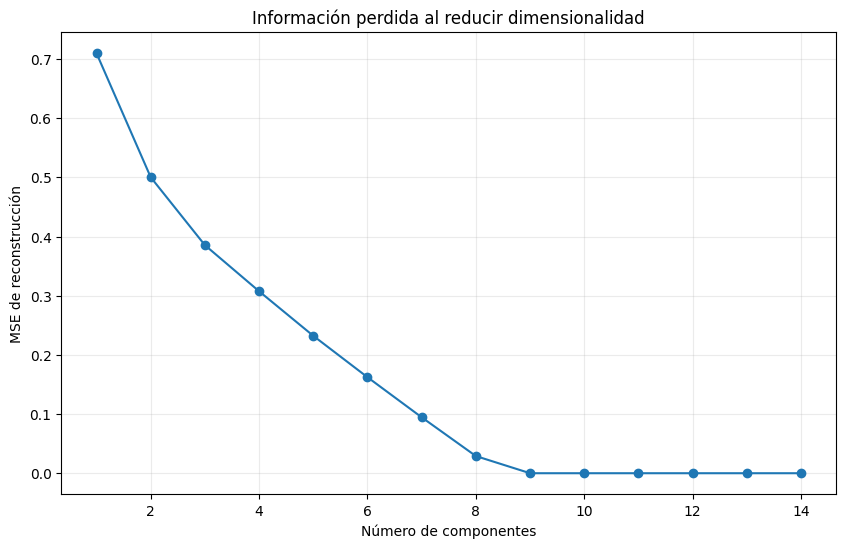

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(
    reconstruction_table["Número de componentes"],
    reconstruction_table["Error de reconstrucción"],
    marker="o",
)
plt.xlabel("Número de componentes")
plt.ylabel("MSE de reconstrucción")
plt.title("Información perdida al reducir dimensionalidad")
plt.grid(alpha=0.25)
plt.show()


## 15. Limitaciones de PCA

PCA:

- es lineal;
- maximiza varianza, no capacidad predictiva;
- es sensible al escalamiento;
- puede ser sensible a outliers;
- produce componentes difíciles de interpretar;
- no necesariamente conserva estructuras no lineales;
- no utiliza la variable objetivo.

## 16. Errores frecuentes

1. Aplicar PCA sin centrar o escalar cuando las unidades son distintas.
2. Ajustar PCA antes del split.
3. Seleccionar componentes usando test.
4. Interpretar componentes como variables causales.
5. Pensar que la primera componente siempre es la más predictiva.
6. Usar dos componentes solo porque son fáciles de visualizar.
7. Ignorar la pérdida de interpretabilidad.
8. Suponer que mayor varianza siempre significa más información útil.
9. No revisar outliers.
10. Aplicar PCA automáticamente a cualquier dataset.

## 17. Experimentos sugeridos

### Experimento 1

Cambia el umbral de varianza retenida:

```python
0.80, 0.90, 0.95, 0.99
```

### Experimento 2

Compara PCA con y sin escalamiento.

### Experimento 3

Agrega variables redundantes y observa el número de componentes necesarias.

### Experimento 4

Agrega variables de ruido.

### Experimento 5

Introduce outliers.

### Experimento 6

Compara desempeño y tiempo de entrenamiento con y sin PCA.

### Experimento 7

Usa PCA antes de KNN.

### Experimento 8

Analiza los loadings de las primeras cinco componentes.

### Experimento 9

Reconstruye observaciones usando distintos números de componentes.

### Experimento 10

Compara PCA con una selección directa de variables.

## 18. Resumen

En este notebook:

- visualizamos la intuición geométrica de PCA;
- transformamos variables correlacionadas;
- analizamos componentes y loadings;
- estudiamos varianza explicada y acumulada;
- redujimos datos a una dimensión;
- reconstruimos observaciones;
- seleccionamos componentes por proporción de varianza;
- visualizamos datos multiclase en dos dimensiones;
- incorporamos PCA en un pipeline;
- analizamos su efecto sobre clasificación;
- discutimos escalamiento, interpretación y limitaciones.

PCA es una herramienta poderosa para condensar información redundante, pero debe usarse con un objetivo claro y dentro de un proceso de validación correcto.